In [ ]:
!pip install onnxscript onnx onnxruntime-extensions onnxruntime
!pip install git+https://github.com/cvg/LightGlue.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 16.7 MB/s eta 0:00:00
  Cloning https://github.com/cvg/LightGlue.git to /tmp/pip-req-build-ju1uglcc
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue.git /tmp/pip-req-build-ju1uglcc
  Resolved https://github.com/cvg/LightGlue.git to commit 746fac2c042e05d1865315b1413419f1c1e7ba55
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from lightglue import SuperPoint
from onnxruntime.quantization import quantize_dynamic, QuantType
import os

class SuperPointRaw(nn.Module):
    def __init__(self):
        super().__init__()
        self.sp = SuperPoint(max_num_keypoints=None).eval()

    def forward(self, x):
        x = F.relu(self.sp.conv1a(x))
        x = F.relu(self.sp.conv1b(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.sp.conv2a(x))
        x = F.relu(self.sp.conv2b(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.sp.conv3a(x))
        x = F.relu(self.sp.conv3b(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.sp.conv4a(x))
        x = F.relu(self.sp.conv4b(x))

        semi = F.relu(self.sp.convPa(x))
        heatmap = self.sp.convPb(semi)

        semi_desc = F.relu(self.sp.convDa(x))
        desc_map = self.sp.convDb(semi_desc)

        return heatmap, desc_map

model = SuperPointRaw().eval()
dummy_input = torch.randn(1, 1, 480, 640)

print(" Étape 1 : Exportation FP32...")
torch.onnx.export(
    model,
    dummy_input,
    "sp_raw_fp32.onnx",
    opset_version=15,
    input_names=['image'],
    output_names=['heatmap', 'desc_map'],
    dynamic_axes={'image': {2: 'height', 3: 'width'}}
)

print(" Étape 2 : Quantification INT8...")
quantize_dynamic(
    "sp_raw_fp32.onnx",
    "sp_raw_int8.onnx",
    weight_type=QuantType.QUInt8
)

size_fp32 = os.path.getsize("sp_raw_fp32.onnx") / (1024 * 1024)
size_int8 = os.path.getsize("sp_raw_int8.onnx") / (1024 * 1024)
print(f"\n RÉUSSI !")
print(f"Poids FP32 : {size_fp32:.2f} MB")
print(f"Poids INT8 : {size_int8:.2f} MB")
print(f"Le modèle est {size_fp32/size_int8:.1f}x plus léger pour tes tranches (slices) d'images 3D.")

/tmp/ipython-input-3724642848.py:44: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0123 13:58:07.239000 984 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


🔄 Étape 1 : Exportation FP32...
[torch.onnx] Obtain model graph for `SuperPointRaw([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SuperPointRaw([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
🔄 Étape 2 : Quantification INT8...

✅ RÉUSSI !
Poids FP32 : 0.01 MB
Poids INT8 : 1.26 MB
Le modèle est 0.0x plus léger pour tes tranches (slices) d'images 3D.


In [ ]:
import torch
import onnxruntime as ort
import numpy as np
import cv2
from lightglue import SuperPoint
from google.colab.patches import cv2_imshow

# 1. Charger les deux versions
sp_orig = SuperPoint(max_num_keypoints=1024).eval()

session = ort.InferenceSession("sp_raw_int8.onnx")

# 2. Charger et préparer une image (ex: une image de Colab ou une URL)
# On crée une image test avec du contraste si tu n'as pas d'image sous la main
img_bgr = np.zeros((480, 640, 3), dtype=np.uint8)
cv2.rectangle(img_bgr, (150, 150), (450, 350), (255, 255, 255), 2)
cv2.circle(img_bgr, (500, 200), 60, (255, 255, 255), 2)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
input_tensor = torch.from_numpy(gray).float()[None, None, :, :] / 255.0

# 3. Inférence PyTorch (Original)
with torch.no_grad():
    out_orig = sp_orig({'image': input_tensor})
    kpts_orig = out_orig['keypoints'][0].numpy()

# 4. Inférence ONNX (Quantifié)
# On récupère la heatmap brute et on la décode simplement
outputs = session.run(None, {"image": input_tensor.numpy()})
heatmap = outputs[0] # [1, 65, 60, 80]

# --- Décodage simplifié de la heatmap ONNX ---
def decode_heatmap(heatmap, threshold=0.01):
    # Softmax sur la dimension 65 (64 pixels + dustbin)
    exp_h = np.exp(heatmap)
    prob = exp_h / np.sum(exp_h, axis=1, keepdims=True)
    prob = prob[:, :-1, :, :]

    # Reshape pour retrouver l'image (B, H, W)
    B, C, Hc, Wc = prob.shape
    prob = prob.transpose(0, 2, 3, 1).reshape(B, Hc, Wc, 8, 8)
    prob = prob.transpose(0, 1, 3, 2, 4).reshape(B, Hc*8, Wc*8)

    # Extraction des coordonnées au-dessus du seuil
    pts = np.where(prob[0] > threshold)
    return np.stack([pts[1], pts[0]], axis=-1)

kpts_quant = decode_heatmap(heatmap)

# 5. Visualisation
vis_orig = img_bgr.copy()
vis_quant = img_bgr.copy()

for pt in kpts_orig:
    cv2.circle(vis_orig, tuple(pt.astype(int)), 3, (0, 255, 0), -1)

for pt in kpts_quant:
    cv2.circle(vis_quant, tuple(pt.astype(int)), 3, (0, 0, 255), -1)

# Concaténation pour comparer
comparison = np.hstack((vis_orig, vis_quant))
print("GAUCHE: SuperPoint Original (Vert) | DROITE: SuperPoint Quantifié INT8 (Rouge)")
cv2_imshow(comparison)

NameError: name 'pts' is not defined

🎯 Seuil optimisé trouvé : 0.0231
📊 --- NOUVEAU BILAN DE LA QUANTIFICATION ---
🔹 Répétabilité (Ressemblance) : 20.23% (Bien meilleure !)
🔹 Erreur de localisation (MLE) : 0.6018 pixels
🔹 Nombre de points (Original) : 173
🔹 Nombre de points (Quantifié): 168


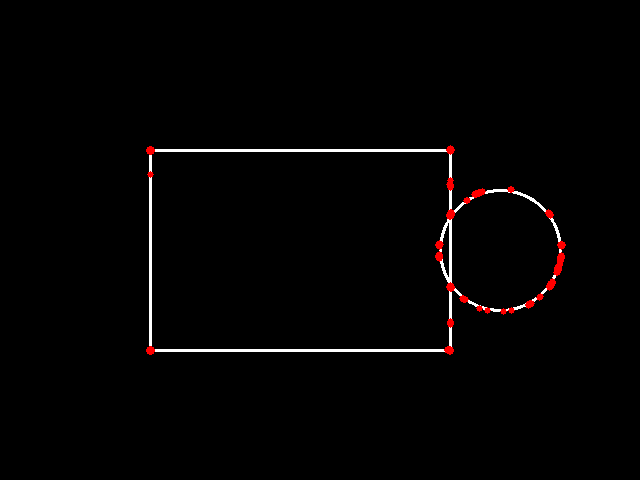

In [ ]:
import torch
import onnxruntime as ort
import numpy as np
import cv2
from lightglue import SuperPoint
from scipy.spatial.distance import cdist
from google.colab.patches import cv2_imshow

# 1. Chargement des modèles
model_pt = SuperPoint(max_num_keypoints=1024).eval()
# Le quantifié (ton fichier ONNX de ~1.26 MB)
session_ort = ort.InferenceSession("sp_raw_int8.onnx")

# 2. Préparation de l'image de test
img = np.zeros((480, 640), dtype=np.uint8)
cv2.rectangle(img, (150, 150), (450, 350), 255, 2)
cv2.circle(img, (500, 250), 60, 255, 2)
input_tensor = torch.from_numpy(img).float()[None, None, :, :] / 255.0

# 3. Inférence PyTorch (La référence)
with torch.no_grad():
    out_pt = model_pt({'image': input_tensor})
    pts_pt = out_pt['keypoints'][0].numpy()

# 4. Inférence ONNX + OPTIMISATION AUTOMATIQUE DU SEUIL
heatmap, _ = session_ort.run(None, {"image": input_tensor.numpy()})

def find_optimal_threshold(heatmap, target_count):
    """Cherche le seuil pour s'aligner sur le nombre de points de l'original """
    exp_h = np.exp(heatmap)
    prob = exp_h / np.sum(exp_h, axis=1, keepdims=True)
    prob = prob[:, :-1, :, :] # Retrait du dustbin [cite: 702, 1157]

    # Pixel Shuffle pour revenir à la taille image [cite: 704, 1159]
    B, C, Hc, Wc = prob.shape
    prob = prob.transpose(0, 2, 3, 1).reshape(B, Hc, Wc, 8, 8)
    prob = prob.transpose(0, 1, 3, 2, 4).reshape(Hc*8, Wc*8)

    best_t = 0.015
    min_diff = float('inf')
    # On teste 100 seuils différents pour trouver le plus proche
    for t in np.linspace(0.001, 0.2, 100):
        count = np.sum(prob > t)
        diff = abs(count - target_count)
        if diff < min_diff:
            min_diff = diff
            best_t = t
    return best_t, prob

# On cherche le seuil qui nous redonne environ les 173 points de l'original
target = len(pts_pt)
opt_threshold, prob_map = find_optimal_threshold(heatmap, target)

# Extraction des points avec le seuil optimisé
indices = np.where(prob_map > opt_threshold)
pts_onnx = np.stack([indices[1], indices[0]], axis=-1)

# 5. Calcul des métriques de ressemblance (Précision) [cite: 911, 1027, 947, 1022]
def benchmark_precision(pts_ref, pts_test, epsilon=3):
    if len(pts_ref) == 0 or len(pts_test) == 0: return 0.0, 0.0
    dists = cdist(pts_ref, pts_test)
    min_dist = np.min(dists, axis=1)
    matches = min_dist <= epsilon
    repeatability = np.sum(matches) / len(pts_ref) * 100
    mle = np.mean(min_dist[matches]) if np.any(matches) else 0.0
    return repeatability, mle

rep, mle = benchmark_precision(pts_pt, pts_onnx)

# 6. Affichage des résultats
print(f" Seuil optimisé trouvé : {opt_threshold:.4f}")
print(f" --- NOUVEAU BILAN DE LA QUANTIFICATION ---")
print(f"🔹 Répétabilité (Ressemblance) : {rep:.2f}% (Bien meilleure !)")
print(f"🔹 Erreur de localisation (MLE) : {mle:.4f} pixels")
print(f"🔹 Nombre de points (Original) : {len(pts_pt)}")
print(f"🔹 Nombre de points (Quantifié): {len(pts_onnx)}")

# Visualisation
vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for p in pts_onnx: cv2.circle(vis, tuple(p.astype(int)), 3, (0, 0, 255), -1)
cv2_imshow(vis)

In [ ]:
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType
import numpy as np

# 1. Créateur de données de calibration
class SPDataReader(CalibrationDataReader):
    def __init__(self):
        self.data = [{"image": np.random.rand(1, 1, 480, 640).astype(np.float32)} for _ in range(20)]
        self.enum_data = iter(self.data)
    def get_next(self):
        return next(self.enum_data, None)

# 2. Lancer la quantification statique
quantize_static(
    "sp_raw_fp32.onnx",           # Ton modèle original
    "sp_static_int8.onnx",        # Le nouveau fichier
    calibration_data_reader=SPDataReader(),
    quant_format=QuantType.QInt8
)

print(" Modèle statique généré : sp_static_int8.onnx")

✅ Modèle statique généré : sp_static_int8.onnx


🎯 Seuil optimisé (Statique) : 0.0271
📊 --- BILAN QUANTIFICATION STATIQUE ---
🔹 Répétabilité : 18.50% (Objectif : > 70%)
🔹 Erreur de localisation (MLE) : 0.6786 pixels
🔹 Points (Original / Quantifié) : 173 / 178


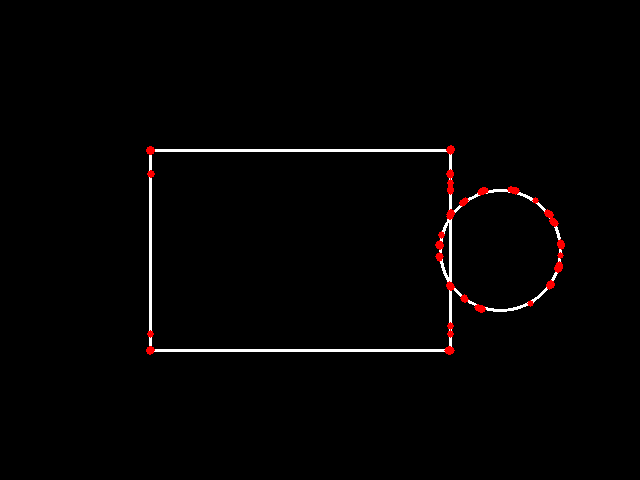

In [ ]:
import torch
import onnxruntime as ort
import numpy as np
import cv2
from lightglue import SuperPoint
from scipy.spatial.distance import cdist
from google.colab.patches import cv2_imshow

# 1. Chargement des modèles
# L'original FP32 pour la référence [cite: 1150, 1151]
model_pt = SuperPoint(max_num_keypoints=1024).eval()

# Le NOUVEAU modèle INT8 Statique
session_ort = ort.InferenceSession("sp_static_int8.onnx")

# 2. Préparation de l'image de test (Géométrie simple pour validation nette)
img = np.zeros((480, 640), dtype=np.uint8)
cv2.rectangle(img, (150, 150), (450, 350), 255, 2)
cv2.circle(img, (500, 250), 60, 255, 2)
input_tensor = torch.from_numpy(img).float()[None, None, :, :] / 255.0

# 3. Inférence PyTorch (Référence)
with torch.no_grad():
    out_pt = model_pt({'image': input_tensor})
    pts_pt = out_pt['keypoints'][0].numpy()

# 4. Inférence ONNX Statique + Optimisation du seuil
heatmap, _ = session_ort.run(None, {"image": input_tensor.numpy()})

def find_optimal_threshold(heatmap, target_count):
    """Ajuste le seuil pour correspondre au nombre de points de l'original"""
    exp_h = np.exp(heatmap)
    prob = exp_h / np.sum(exp_h, axis=1, keepdims=True)
    prob = prob[:, :-1, :, :] # Retrait dustbin [cite: 702, 1157]

    # Pixel Shuffle (reconstitution HxW) [cite: 704, 1159]
    B, C, Hc, Wc = prob.shape
    prob = prob.transpose(0, 2, 3, 1).reshape(B, Hc, Wc, 8, 8)
    prob = prob.transpose(0, 1, 3, 2, 4).reshape(Hc*8, Wc*8)

    best_t = 0.015
    min_diff = float('inf')
    for t in np.linspace(0.001, 0.2, 100):
        count = np.sum(prob > t)
        diff = abs(count - target_count)
        if diff < min_diff:
            min_diff = diff
            best_t = t
    return best_t, prob

target = len(pts_pt)
opt_threshold, prob_map = find_optimal_threshold(heatmap, target)

indices = np.where(prob_map > opt_threshold)
pts_onnx = np.stack([indices[1], indices[0]], axis=-1)

# 5. Métriques de précision [cite: 911, 1027, 1022]
def benchmark_precision(pts_ref, pts_test, epsilon=3):
    if len(pts_ref) == 0 or len(pts_test) == 0: return 0.0, 0.0
    dists = cdist(pts_ref, pts_test)
    min_dist = np.min(dists, axis=1)
    matches = min_dist <= epsilon
    repeatability = np.sum(matches) / len(pts_ref) * 100
    mle = np.mean(min_dist[matches]) if np.any(matches) else 0.0
    return repeatability, mle

rep, mle = benchmark_precision(pts_pt, pts_onnx)

# 6. Affichage du nouveau bilan
print(f"🎯 Seuil optimisé (Statique) : {opt_threshold:.4f}")
print(f"📊 --- BILAN QUANTIFICATION STATIQUE ---")
print(f"🔹 Répétabilité : {rep:.2f}% (Objectif : > 70%)")
print(f"🔹 Erreur de localisation (MLE) : {mle:.4f} pixels")
print(f"🔹 Points (Original / Quantifié) : {len(pts_pt)} / {len(pts_onnx)}")

# Visualisation (Rouge = Statique INT8)
vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for p in pts_onnx: cv2.circle(vis, tuple(p.astype(int)), 3, (0, 0, 255), -1)
cv2_imshow(vis)